In [1]:
import pyBigWig
import sklearn.metrics
from sklearn.metrics import roc_auc_score

import matplotlib

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42 

In [2]:
auprcs = []
aurocs = []
for readdepth in [ "572M", "250M", "100M", "50M", "25M", "15M", "10M" , "5M", "2M" ]:
    for foldn in ["fold0"]:

        import pandas as pd
        #foldn="fold0"
        bed_annotate = "/mnt/lab_data2/anusri/chrombpnet/results/chrombpnet/auprc_curves/GM12878/idr_overlap_peak_blacklist_annotated_"+foldn+".bed"

        chr1_binned = pd.read_csv(bed_annotate, sep="\t", names=["chr", "start", "end", "idr", "idr_f", "idr_t", "idr_w", "idr_frac", 
                                                                 "bkt", "op"])
        chr1_binned = chr1_binned[:-1]
        print(chr1_binned.shape)

        #chr1_binned["mappability"] = mappability
        chr1_binned["label"] = 0
        chr1_binned.loc[chr1_binned["idr"]==1, "label"] =1
        print(sum(chr1_binned["label"]))

        import numpy as np
        chrm = None
        values = []
        chromsize={}
        chroms = chr1_binned['chr'].unique().tolist()

        for chrm in chroms:
            bww="/mnt/lab_data2/anusri/chrombpnet/results/chrombpnet/auprc_curves/subsampling/"+readdepth+"/"+readdepth+"_"+foldn+"_"+chrm+"_w_bias.bw"
            pred_bigwig = pyBigWig.open(bww,"r")
            chrmsz = pred_bigwig.chroms(chrm)
            print(chrm, chrmsz)


            filtered_df = chr1_binned[chr1_binned['chr'] == chrm]
            chromsize[chrm] = [filtered_df.shape[0], chrmsz]

            all_val = np.nan_to_num(pred_bigwig.values(chrm, 0, chrmsz))
            atac = [sum(all_val[i:i+100]) for i in range(557,chromsize[chrm][1], 100)][0:chromsize[chrm][0]]
            values.extend(atac)
        chr1_binned["atac"] = values

        import numpy as np
        import gzip

        mappability = []
        for chrm in chroms:

            with gzip.open("/mnt/lab_data2/anusri/chrombpnet/reference/mappability/"+chrm+'.uint8.unique.gz', 'rb') as tmp_uMap:
                uMapdata = np.frombuffer(tmp_uMap.read(), dtype=np.uint8)

            pos_vec = (uMapdata>0)&(uMapdata<=101)
            pos_vec = pos_vec.astype(int)
            neg_vec = np.roll(pos_vec, 100)
            neg_vec[0:100] = 0

            print(set(pos_vec))
            print(len(uMapdata))
            print(sum(pos_vec))

            total_map=pos_vec+neg_vec
            mappability.extend([sum(total_map[i:i+100])/200 for i in range(557,chromsize[chrm][1], 100)][0:chromsize[chrm][0]])

        chr1_binned["mappability"] = mappability
        print(sum(chr1_binned["idr"]==1))
        chr1_binned=chr1_binned[chr1_binned["bkt"]==0]
        chr1_binned = chr1_binned[~((chr1_binned["idr_frac"]>0) & (chr1_binned["idr_frac"]<1.0))]
        chr1_binned = chr1_binned[~((chr1_binned["op"]==1) & (chr1_binned["idr"]==0))]
        print(chr1_binned.shape)
        chr1_binned = chr1_binned[chr1_binned["mappability"]>0.5]
        aupr=sklearn.metrics.average_precision_score(chr1_binned["label"],chr1_binned["atac"])
        auproc=roc_auc_score(chr1_binned["label"],  abs(chr1_binned["atac"]))
        print(foldn,np.round(aupr,2),auproc)
        print(sum(chr1_binned["label"])/chr1_binned.shape[0])
        auprcs.append(aupr)
        aurocs.append(auproc)

(6180564, 10)
46163
chr1 248956422
chr3 198295559
chr6 170805979
{0, 1}
248956422
219161958
{0, 1}
198295559
193185515
{0, 1}
170805979
166067589
46163
(5864091, 13)
fold0 0.41 0.9575841991056061
0.008240785740111752
(6180564, 10)
46163
chr1 248956422
chr3 198295559
chr6 170805979
{0, 1}
248956422
219161958
{0, 1}
198295559
193185515
{0, 1}
170805979
166067589
46163
(5864091, 13)
fold0 0.4 0.9593362829547298
0.008240785740111752
(6180564, 10)
46163
chr1 248956422
chr3 198295559
chr6 170805979
{0, 1}
248956422
219161958
{0, 1}
198295559
193185515
{0, 1}
170805979
166067589
46163
(5864091, 13)
fold0 0.38 0.9563373830011344
0.008240785740111752
(6180564, 10)
46163
chr1 248956422
chr3 198295559
chr6 170805979
{0, 1}
248956422
219161958
{0, 1}
198295559
193185515
{0, 1}
170805979
166067589
46163
(5864091, 13)
fold0 0.37 0.9548059283462722
0.008240785740111752
(6180564, 10)
46163
chr1 248956422
chr3 198295559
chr6 170805979
{0, 1}
248956422
219161958
{0, 1}
198295559
193185515
{0, 1}
1708059

In [3]:
import matplotlib.pyplot as plt

/users/anusri/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  if __name__ == '__main__':


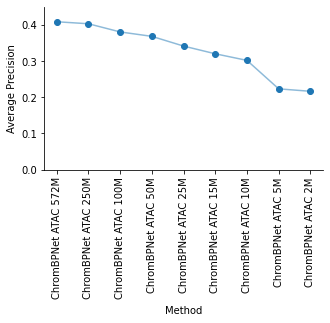

In [4]:
import matplotlib.pyplot as plt
fix, ax = plt.subplots(figsize=(5,3))
ax.scatter(["ATAC\n572M", "ATAC\n250M", "ATAC\n100M" ,"ATAC\n50M", "ATAC\n25M", "ATAC\n15M", "ATAC\n10M", "ATAC\n5M", "ATAC\n2M"],auprcs)
ax.plot(["ATAC\n572M", "ATAC\n250M", "ATAC\n100M" ,"ATAC\n50M", "ATAC\n25M", "ATAC\n15M", "ATAC\n10M", "ATAC\n5M", "ATAC\n2M"],auprcs, alpha=0.5)
xtix=["ChromBPNet ATAC 572M", " ChromBPNet ATAC 250M", "ChromBPNet ATAC 100M","ChromBPNet ATAC 50M", "ChromBPNet ATAC 25M", "ChromBPNet ATAC 15M", "ChromBPNet ATAC 10M", "ChromBPNet ATAC 5M", "ChromBPNet ATAC 2M"]

ax.set_ylim((0,0.45))
ax.spines[["top", "right"]].set_visible(False)
ax.set_xticklabels(labels=xtix, rotation=90)
ax.set_xlabel("Method")
ax.set_ylabel("Average Precision")
plt.savefig("figures/subsampled_data_AP_bg.pdf", dpi=300, transparent=True)


/users/anusri/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  if __name__ == '__main__':


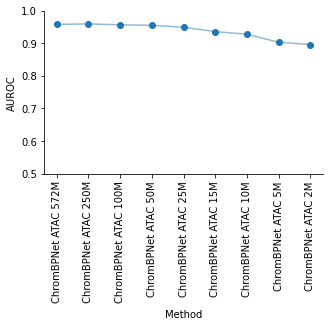

In [5]:
import matplotlib.pyplot as plt
fix, ax = plt.subplots(figsize=(5,3))
ax.scatter(["ATAC\n572M", "ATAC\n250M", "ATAC\n100M" ,"ATAC\n50M", "ATAC\n25M", "ATAC\n15M", "ATAC\n10M", "ATAC\n5M", "ATAC\n2M"],aurocs)
ax.plot(["ATAC\n572M", "ATAC\n250M", "ATAC\n100M" ,"ATAC\n50M", "ATAC\n25M", "ATAC\n15M", "ATAC\n10M", "ATAC\n5M", "ATAC\n2M"],aurocs, alpha=0.5)
xtix=["ChromBPNet ATAC 572M", " ChromBPNet ATAC 250M", "ChromBPNet ATAC 100M","ChromBPNet ATAC 50M", "ChromBPNet ATAC 25M", "ChromBPNet ATAC 15M", "ChromBPNet ATAC 10M", "ChromBPNet ATAC 5M", "ChromBPNet ATAC 2M"]

ax.set_ylim((0.5,1.0))
ax.spines[["top", "right"]].set_visible(False)
ax.set_xticklabels(labels=xtix, rotation=90)
ax.set_xlabel("Method")
ax.set_ylabel("AUROC")
plt.savefig("figures/subsampled_data_AUROC_bg.pdf", dpi=300, transparent=True)


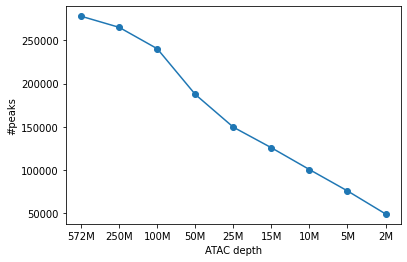

In [6]:
depth = ["572M", "250M", "100M", "50M", "25M", "15M", "10M", "5M", "2M"]
peaks = [277907, 265030, 240287, 187344, 149430, 125597, 100349, 75601, 48963]
plt.scatter(depth,peaks)
plt.plot(depth,peaks)
plt.ylabel("#peaks")
plt.xlabel("ATAC depth")
plt.savefig("figures/subsampled_data_peaks_num.pdf", dpi=300, transparent=True)


/users/anusri/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  # This is added back by InteractiveShellApp.init_path()
/users/anusri/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:21: UserWarning: FixedFormatter should only be used together with FixedLocator


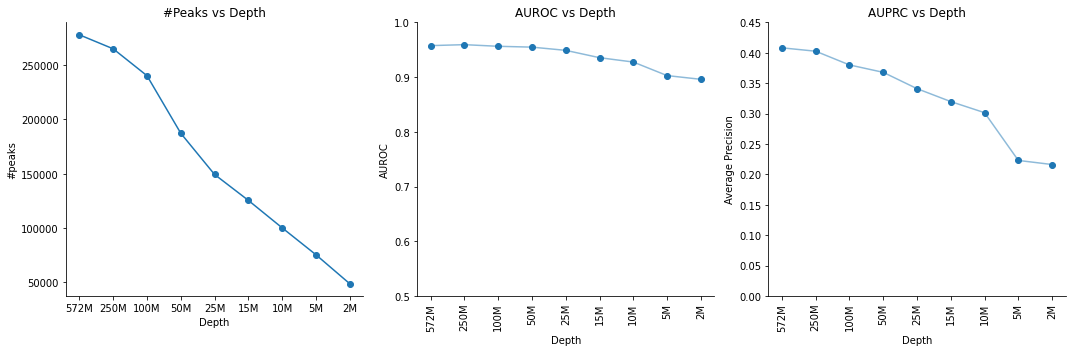

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
depth = ["572M", "250M", "100M", "50M", "25M", "15M", "10M", "5M", "2M"]
xtix = ["572M", "250M", "100M", "50M", "25M", "15M", "10M", "5M", "2M"]

# Plot 1: AUPRC
idx=2
axes[idx].scatter(xtix, auprcs)
axes[idx].plot(xtix, auprcs, alpha=0.5)
axes[idx].set_ylim((0, 0.45))
axes[idx].spines[["top", "right"]].set_visible(False)
axes[idx].set_xticklabels(labels=xtix, rotation=90)
axes[idx].set_xlabel("Depth")
axes[idx].set_ylabel("Average Precision")
axes[idx].set_title("AUPRC vs Depth")

# Plot 2: AUROC
axes[1].scatter(xtix, aurocs)
axes[1].plot(xtix, aurocs, alpha=0.5)
axes[1].set_ylim((0.5, 1.0))
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].set_xticklabels(labels=xtix, rotation=90)
axes[1].set_xlabel("Depth")
axes[1].set_ylabel("AUROC")
axes[1].set_title("AUROC vs Depth")

# Plot 3: Peaks
idx=0
axes[idx].scatter(xtix, peaks)
axes[idx].plot(xtix, peaks)
axes[idx].set_xlabel("Depth")
axes[idx].set_ylabel("#peaks")
axes[idx].set_title("#Peaks vs Depth")
axes[idx].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("figures/subsampled_data_combined.pdf", dpi=300, transparent=True)
plt.show()